In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from scipy.stats import shapiro, normaltest, anderson
from scipy.stats import pearsonr, spearmanr, kendalltau
 
np.random.seed(42)  # kad rezultatai būtų atkartojami

In [2]:
n = 500
 
x_normal = np.random.normal(loc=0, scale=1, size=n)
x_lognormal = np.random.lognormal(mean=0.0, sigma=0.6, size=n)
 
x_outliers = x_normal.copy()
x_outliers[:5] = x_outliers[:5] + 8  # 5 didelės išskirtys
 
df = pd.DataFrame({
    "x_normal": x_normal,
    "x_lognormal": x_lognormal,
    "x_outliers": x_outliers
})
 
df.head()

,x_normal,x_lognormal,x_outliers
0,0.496714,1.743172,8.496714
1,-0.138264,3.144485,7.861736
2,0.647689,0.432082,8.647689
3,1.523030,1.401834,9.523030
4,-0.234153,0.676796,7.765847


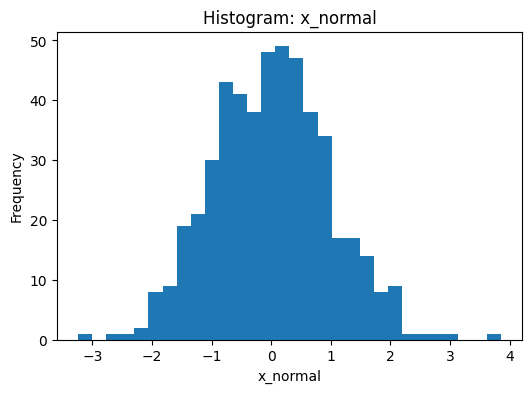

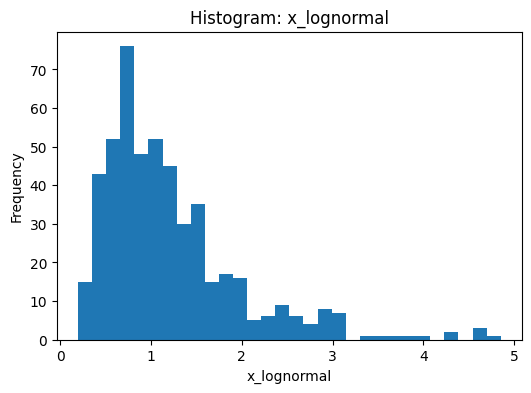

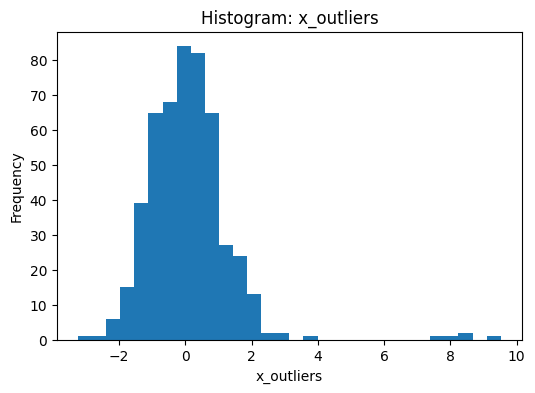

In [3]:
cols = ["x_normal", "x_lognormal", "x_outliers"]
 
for col in cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [4]:
def run_shapiro(series, name):
    stat, p = shapiro(series)
    print(f"{name}: W={stat:.4f}, p-value={p:.3e}")
 
for col in cols:
    run_shapiro(df[col], col)

x_normal: W=0.9967, p-value=4.013e-01
x_lognormal: W=0.8489, p-value=1.818e-21
x_outliers: W=0.8125, p-value=1.108e-23


In [5]:
def run_normaltest(series, name):
    stat, p = normaltest(series)
    print(f"{name}: stat={stat:.4f}, p-value={p:.3e}")
 
for col in cols:
    run_normaltest(df[col], col)

x_normal: stat=4.2235, p-value=1.210e-01
x_lognormal: stat=186.8058, p-value=2.727e-41
x_outliers: stat=344.8469, p-value=1.311e-75


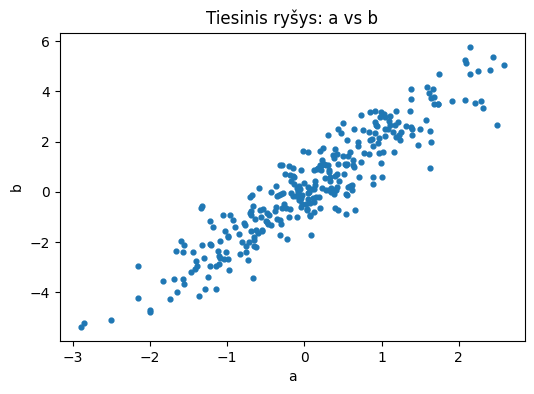

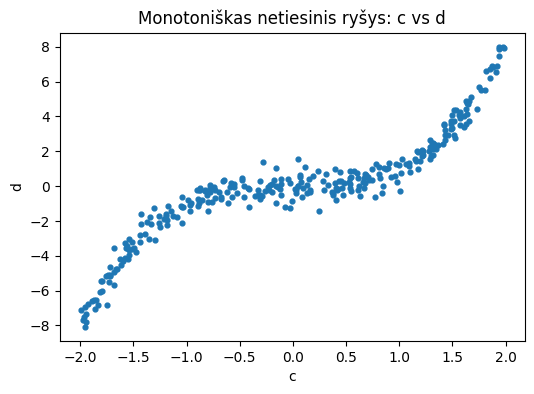

In [6]:
n = 300
 
a = np.random.normal(0, 1, n)
b = 2.0 * a + np.random.normal(0, 0.8, n)
 
c = np.random.uniform(-2, 2, n)
d = c**3 + np.random.normal(0, 0.5, n)
 
plt.figure(figsize=(6,4))
plt.scatter(a, b, s=12)
plt.title("Tiesinis ryšys: a vs b")
plt.xlabel("a")
plt.ylabel("b")
plt.show()
 
plt.figure(figsize=(6,4))
plt.scatter(c, d, s=12)
plt.title("Monotoniškas netiesinis ryšys: c vs d")
plt.xlabel("c")
plt.ylabel("d")
plt.show()

In [7]:
def corr_report(x, y, label):
    r_p, p_p = pearsonr(x, y)
    r_s, p_s = spearmanr(x, y)
    r_k, p_k = kendalltau(x, y)
    print(label)
    print(f"  Pearson   r={r_p:.3f}, p={p_p:.3e}")
    print(f"  Spearman  r={r_s:.3f}, p={p_s:.3e}")
    print(f"  Kendall τ r={r_k:.3f}, p={p_k:.3e}")
    print()
 
corr_report(a, b, "a vs b (tiesinis)")
corr_report(c, d, "c vs d (monotoniškas netiesinis)")
 

a vs b (tiesinis)
  Pearson   r=0.928, p=1.074e-129
  Spearman  r=0.919, p=3.746e-122
  Kendall τ r=0.755, p=1.241e-84

c vs d (monotoniškas netiesinis)
  Pearson   r=0.907, p=2.844e-114
  Spearman  r=0.939, p=1.315e-140
  Kendall τ r=0.822, p=4.084e-100

